In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [26]:

land_registry_folder = Path(
    "/Users/bibhrajsaha/uk-housing-intelligence-platform/data/raw/land_registry"
)

land_registry_files = sorted(
    land_registry_folder.glob("pp-*.csv")
)

land_registry_files

[PosixPath('/Users/bibhrajsaha/uk-housing-intelligence-platform/data/raw/land_registry/pp-2023.csv'),
 PosixPath('/Users/bibhrajsaha/uk-housing-intelligence-platform/data/raw/land_registry/pp-2024.csv'),
 PosixPath('/Users/bibhrajsaha/uk-housing-intelligence-platform/data/raw/land_registry/pp-2025.csv'),
 PosixPath('/Users/bibhrajsaha/uk-housing-intelligence-platform/data/raw/land_registry/pp-2026.csv')]

In [27]:
house_dfs = []

for file in land_registry_files:

    temp_df = pd.read_csv(
        file,
        header=None
    )

    house_dfs.append(temp_df)

house_df = pd.concat(
    house_dfs,
    ignore_index=True
)

In [31]:
house_df.columns

Index(['transaction_id', 'price', 'date_of_transfer', 'postcode',
       'property_type', 'old_new', 'duration', 'paon', 'saon', 'street',
       'locality', 'town_city', 'district', 'county', 'ppd_category_type',
       'record_status'],
      dtype='str')

In [32]:
house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2816596 entries, 0 to 2816595
Data columns (total 16 columns):
 #   Column             Dtype
---  ------             -----
 0   transaction_id     str  
 1   price              int64
 2   date_of_transfer   str  
 3   postcode           str  
 4   property_type      str  
 5   old_new            str  
 6   duration           str  
 7   paon               str  
 8   saon               str  
 9   street             str  
 10  locality           str  
 11  town_city          str  
 12  district           str  
 13  county             str  
 14  ppd_category_type  str  
 15  record_status      str  
dtypes: int64(1), str(15)
memory usage: 668.4 MB


In [33]:
house_df.head()

,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category_type,record_status
0,{01EB45F0-6229-40F3-E063-4704A8C05FDE},208000,2023-06-14 00:00,RH15 0DZ,F,N,L,62,NaN,THE WARREN,NaN,BURGESS HILL,MID SUSSEX,WEST SUSSEX,A,A
1,{01EB45F0-622A-40F3-E063-4704A8C05FDE},193000,2023-02-10 00:00,BN13 1NT,F,N,L,"CATHERINE LODGE, 52",FLAT 31,BOLSOVER ROAD,NaN,WORTHING,WORTHING,WEST SUSSEX,A,A
2,{01EB45F0-622B-40F3-E063-4704A8C05FDE},185000,2023-05-26 00:00,BN11 2BU,F,N,L,MARIK MEWS,FLAT 3,SELDEN LANE,NaN,WORTHING,WORTHING,WEST SUSSEX,A,A
3,{01EB45F0-622C-40F3-E063-4704A8C05FDE},187500,2023-06-09 00:00,BN16 3BJ,F,N,L,ABBOTSWOOD,FLAT 34,STATION ROAD,RUSTINGTON,LITTLEHAMPTON,ARUN,WEST SUSSEX,A,A
4,{01EB45F0-622D-40F3-E063-4704A8C05FDE},265000,2023-06-28 00:00,BN11 4JS,F,N,L,"ASPEN COURT, 40 - 42",FLAT 9,ST BOTOLPHS ROAD,NaN,WORTHING,WORTHING,WEST SUSSEX,A,A


In [28]:
house_df.columns = [
    "transaction_id",
    "price",
    "date_of_transfer",
    "postcode",
    "property_type",
    "old_new",
    "duration",
    "paon",
    "saon",
    "street",
    "locality",
    "town_city",
    "district",
    "county",
    "ppd_category_type",
    "record_status"
]

In [29]:
house_df.shape

(2816596, 16)

In [30]:
house_df.describe()

,price
count,2.816596e+06
mean,3.934916e+05
std,1.257611e+06
min,1.000000e+00
25%,1.800000e+05
50%,2.800000e+05
75%,4.250000e+05
max,7.930200e+08


In [34]:
house_df.isnull().sum()

transaction_id             0
price                      0
date_of_transfer           0
postcode                7061
property_type              0
old_new                    0
duration                   0
paon                       0
saon                 2456839
street                 45269
locality             1748211
town_city                  0
district                   0
county                     0
ppd_category_type          0
record_status              0
dtype: int64

In [35]:
(house_df.isnull().sum() / len(house_df)) * 100

transaction_id        0.000000
price                 0.000000
date_of_transfer      0.000000
postcode              0.250693
property_type         0.000000
old_new               0.000000
duration              0.000000
paon                  0.000000
saon                 87.227242
street                1.607224
locality             62.068220
town_city             0.000000
district              0.000000
county                0.000000
ppd_category_type     0.000000
record_status         0.000000
dtype: float64

In [36]:
house_df.duplicated().sum()

np.int64(0)

In [37]:
house_df["price"].describe()

count    2.816596e+06
mean     3.934916e+05
std      1.257611e+06
min      1.000000e+00
25%      1.800000e+05
50%      2.800000e+05
75%      4.250000e+05
max      7.930200e+08
Name: price, dtype: float64

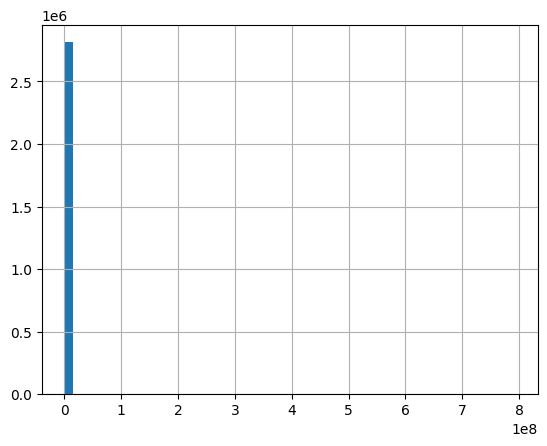

In [38]:
house_df["price"].hist(bins=50)

plt.show()

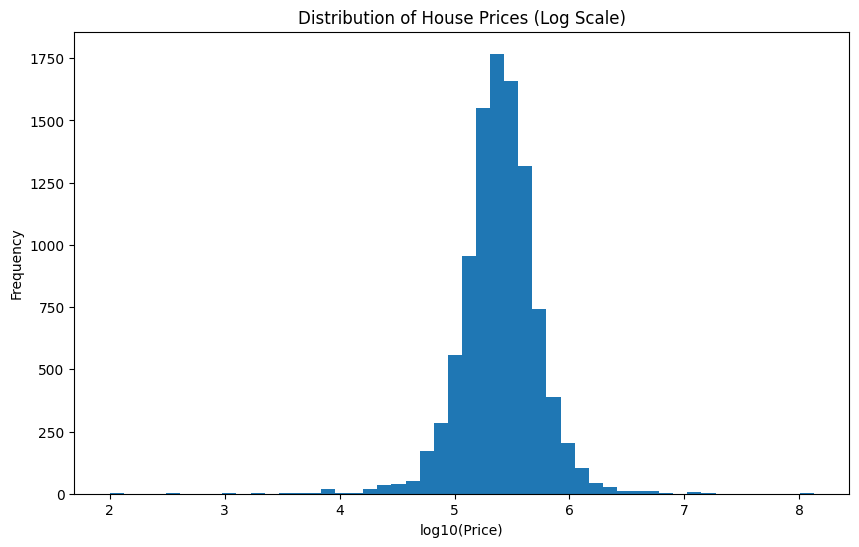

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(np.log10(house_df["price"]), bins=50)

plt.title("Distribution of House Prices (Log Scale)")
plt.xlabel("log10(Price)")
plt.ylabel("Frequency")

plt.show()

In [39]:
house_df["price"].quantile([0.5, 0.9, 0.95, 0.99, 0.999])

0.500      280000.0
0.900      650000.0
0.950      870000.0
0.990     1920000.0
0.999    10500000.0
Name: price, dtype: float64

In [40]:
house_df.groupby("county")["price"].mean().sort_values(ascending=False)

county
GREATER LONDON                797777.683756
WINDSOR AND MAIDENHEAD        717941.146769
SURREY                        654703.383411
BUCKINGHAMSHIRE               599314.463804
HERTFORDSHIRE                 573612.984801
                                  ...      
HARTLEPOOL                    163042.483871
COUNTY DURHAM                 162513.782185
MIDDLESBROUGH                 161705.361287
CITY OF KINGSTON UPON HULL    154731.409281
BLACKPOOL                     151789.611341
Name: price, Length: 114, dtype: float64

In [41]:
county_prices = (
    house_df
    .groupby("county")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

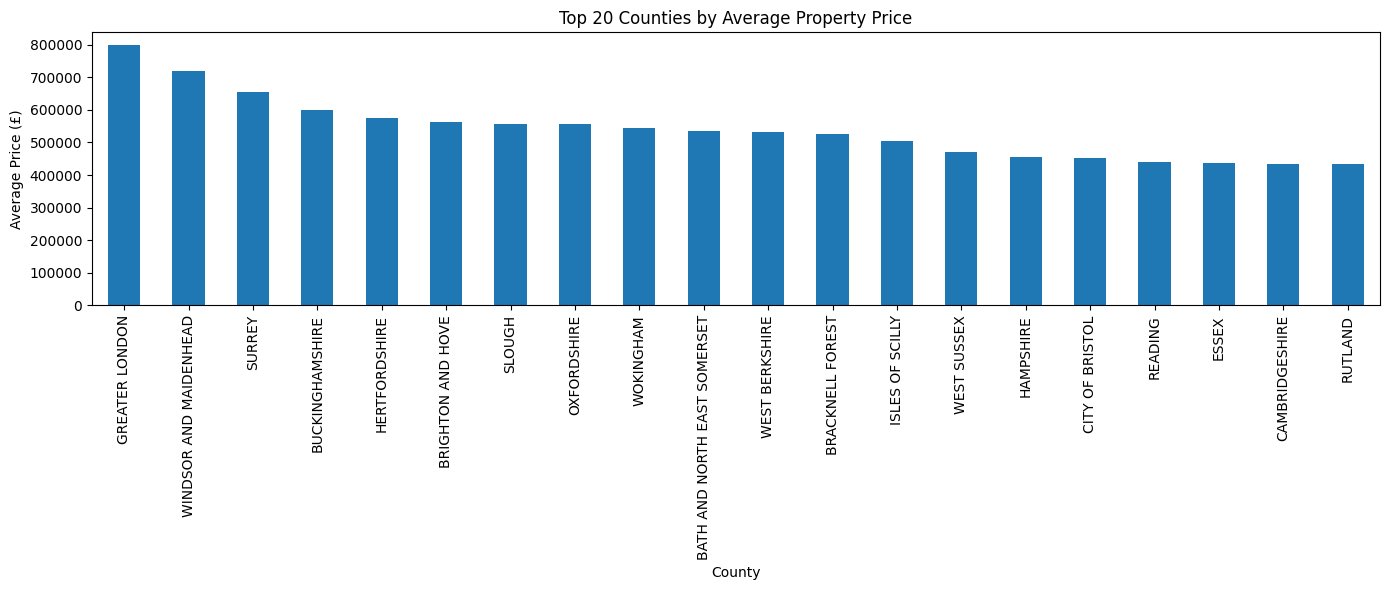

In [42]:
plt.figure(figsize=(14,6))

county_prices.plot(
    kind="bar"
)

plt.title(
    "Top 20 Counties by Average Property Price"
)

plt.xlabel("County")

plt.ylabel(
    "Average Price (£)"
)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/avg_price_by_county.png",
    bbox_inches="tight"
)

plt.show()

In [43]:
house_df["property_type"].value_counts()

property_type
T    776203
S    766287
D    632692
F    493053
O    148361
Name: count, dtype: int64

In [44]:
property_counts = (
    house_df["property_type"]
    .value_counts()
)

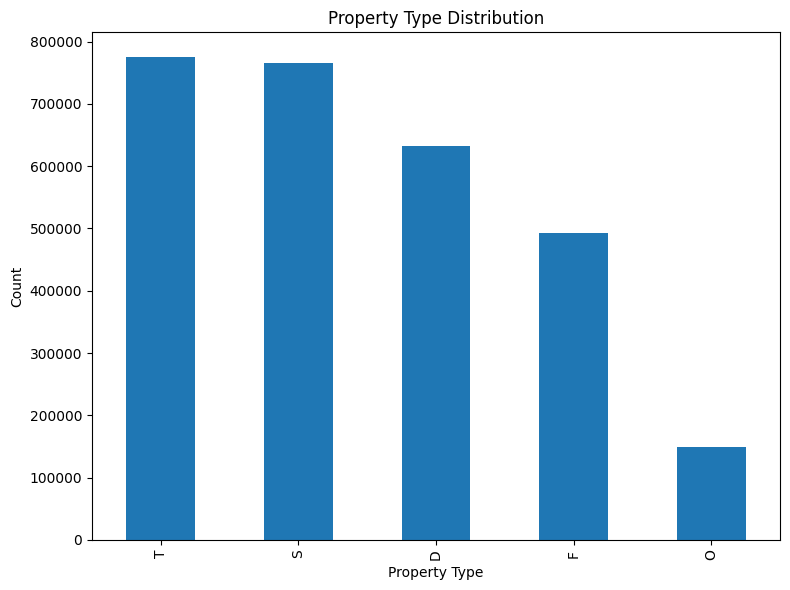

In [45]:
plt.figure(figsize=(8,6))

property_counts.plot(
    kind="bar"
)

plt.title(
    "Property Type Distribution"
)

plt.xlabel("Property Type")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../outputs/plots/property_type_distribution.png",
    bbox_inches="tight"
)

plt.show()